## Importing the Data

In [ ]:
!pip install gensim nlp_id

In [ ]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
pip install fasttext

In [ ]:
pip install tensorflow

In [ ]:
pip install matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
# Constants
DATASET_DIR = '/content/drive/MyDrive/Model+Data/data/'
SAVE_DIR = '/content/drive/MyDrive/Model+Data'


In [ ]:
X = pd.read_csv(os.path.join('/content/drive/MyDrive/Model+Data/data/pre-processed-essay-data-sep.csv'), sep=';', skiprows=1, encoding='ISO-8859-1', decimal=',')
print(X)

                                          kunci jawaban  \
0     Komputer adalah rangkaian mesin elektronik yan...   
1     Komputer adalah rangkaian mesin elektronik yan...   
2     Komputer adalah rangkaian mesin elektronik yan...   
3     Komputer adalah rangkaian mesin elektronik yan...   
4     Komputer adalah rangkaian mesin elektronik yan...   
...                                                 ...   
2157  Otak merupakan bagian terpenting dari tubuh ma...   
2158  Otak merupakan bagian terpenting dari tubuh ma...   
2159  Otak merupakan bagian terpenting dari tubuh ma...   
2160  Otak merupakan bagian terpenting dari tubuh ma...   
2161  Otak merupakan bagian terpenting dari tubuh ma...   

                                                jawaban  score 1  score 2  \
0     Komputer adalah serangkaian ataupun sekelompok...     0.60     0.95   
1                     komputer adalah mesin penghitung      0.10     0.15   
2     mesin yang membantu manusia untuk menjalankan ...     

In [ ]:
X.head()

,kunci jawaban,jawaban,score 1,score 2,score 3
0,Komputer adalah rangkaian mesin elektronik yan...,Komputer adalah serangkaian ataupun sekelompok...,0.60,0.95,0.75
1,Komputer adalah rangkaian mesin elektronik yan...,komputer adalah mesin penghitung,0.10,0.15,0.10
2,Komputer adalah rangkaian mesin elektronik yan...,mesin yang membantu manusia untuk menjalankan ...,0.30,0.20,0.25
3,Komputer adalah rangkaian mesin elektronik yan...,Komputer adalah alat komputasi yang diciptakan...,0.12,0.10,0.10
4,Komputer adalah rangkaian mesin elektronik yan...,alat untuk memudahkan masnusia,0.14,0.10,0.10


In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Create new column with average score
X['domain1_score'] = X[['score 1', 'score 2', 'score 3']].mean(axis=1)

## Defining the model

Here we define a 2-Layer LSTM Model.

Note that instead of using sigmoid activation in the output layer we will use
Relu since we are not normalising training labels.

In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, Conv1D, MaxPooling1D
from tensorflow.keras.models import Sequential

def get_model():
    model = Sequential()

    # Masking (same as before)
    model.add(Masking(mask_value=0.0, input_shape=(80, 300)))

    # --- CNN part ---
    model.add(Conv1D(
        filters=64, kernel_size=3, activation='relu', padding='same'
    ))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(
        filters=128, kernel_size=3, activation='relu', padding='same'
    ))
    model.add(MaxPooling1D(pool_size=2))

    # --- RNN part ---
    model.add(LSTM(64, dropout=0.25, recurrent_dropout=0.2
    ))

    # --- Fully connected ---
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='mae'
    )

    model.summary()
    return model


In [ ]:
import fasttext
import fasttext.util
import numpy as np
from nlp_id.tokenizer import Tokenizer

tokenizer = Tokenizer()

# Load FastText Indonesian model
ft = fasttext.load_model(os.path.join(DATASET_DIR, 'fasttext/cc.id.300.bin'))
embedding_dict = {}

def get_embedding(word):
    """
    Get FastText embedding for a word
    """
    return ft.get_word_vector(word)

# Example: build embedding_dict for a vocabulary
# for word in vocabulary:   # assume `vocabulary` is your word list
#     embedding_dict[word] = get_embedding(word)

def essay_to_sequence_cached(essay_text, ft, max_len):
    words = tokenizer.tokenize(essay_text.lower())   # assuming a suitable tokenizer
    vectors = [ft.get_word_vector(word) for word in words][:max_len]
    # pad with zeros
    if len(vectors) < max_len:
        vectors.extend([np.zeros(EMB_DIM)] * (max_len - len(vectors)))
    return np.array(vectors)


## Training Phase

Now we train the model on the dataset.

We will use 5-Fold Cross Validation and measure the Quadratic Weighted Kappa for each fold.
We will then calculate Average Kappa for all the folds.

In [ ]:
X.index
X.iloc[-1]

,2161
kunci jawaban,Otak merupakan bagian terpenting dari tubuh ma...
jawaban,bila berfikir positif sadar atau tidak sadar p...
score 1,0.22
score 2,0.2
score 3,0.25
domain1_score,0.223333


In [ ]:
y = X['domain1_score']

print(sorted(y.unique()))
print(y.min(), y.max())

[np.float64(0.0), np.float64(0.006666666666666667), np.float64(0.01), np.float64(0.016666666666666666), np.float64(0.02666666666666667), np.float64(0.03333333333333333), np.float64(0.05000000000000001), np.float64(0.05333333333333334), np.float64(0.05666666666666667), np.float64(0.06), np.float64(0.06333333333333334), np.float64(0.06666666666666667), np.float64(0.07), np.float64(0.07333333333333335), np.float64(0.07666666666666667), np.float64(0.08333333333333333), np.float64(0.09000000000000001), np.float64(0.09333333333333334), np.float64(0.09666666666666668), np.float64(0.09999999999999999), np.float64(0.10000000000000002), np.float64(0.10333333333333335), np.float64(0.10666666666666667), np.float64(0.10999999999999999), np.float64(0.11333333333333333), np.float64(0.11333333333333334), np.float64(0.11666666666666665), np.float64(0.12), np.float64(0.12333333333333334), np.float64(0.12666666666666668), np.float64(0.13), np.float64(0.13333333333333333), np.float64(0.1366666666666667), 

In [ ]:
X['domain1_score'].value_counts()

,count
domain1_score,
0.000000,72
1.000000,62
0.266667,55
0.233333,48
0.466667,42
...,...
0.890000,1
0.756667,1
0.806667,1


In [ ]:
import numpy as np
y = X['domain1_score']
# Check if y starts at 0
print("Minimum score:", y.min())
# Check how many nodes the model needs
print("Required NUM_CLASSES:", y.max() + 1)

Minimum score: 0.0
Required NUM_CLASSES: 2.0


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cv = KFold(n_splits=10, shuffle=True, random_state=42)

best_val_r2 = -np.inf
best_fold = None
all_true = []
all_pred = []
fold_ids = []
results = []
histories = []

MAX_LEN = 80   # sequence length
EMB_DIM = 300
NUM_CLASSES = 2
count = 0

y = X['domain1_score'] # Define y as the target variable


for traincv, testcv in cv.split(X):

    print(f"\n-------- Fold {count} --------\n")

    X_train_fold = X.iloc[traincv]
    X_test_fold  = X.iloc[testcv]
    y_train_fold = y.iloc[traincv]
    y_test_fold  = y.iloc[testcv]

    train_essays = X_train_fold["jawaban"]
    test_essays  = X_test_fold["jawaban"]

    # =============================
    # Convert essays → sequences
    # =============================
    X_train_seq = np.array([
        essay_to_sequence_cached(essay, ft, MAX_LEN)
        for essay in train_essays
    ])

    X_test_seq = np.array([
        essay_to_sequence_cached(essay, ft, MAX_LEN)
        for essay in test_essays
    ])
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print("Train shape:", X_train_seq.shape)
    print("Test shape:", X_test_seq.shape)

    # =============================
    # Train LSTM
    # =============================
    model = get_model()
    history = model.fit(
        X_train_seq,
        y_train_fold,
        epochs=50,
        batch_size=32,
        verbose=1,
        validation_split=0.2,
        callbacks=[early_stop]
    )

    histories.append(history)

    # =============================
    # Predict & Evaluate
    # =============================

    y_pred = model.predict(X_test_seq).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred))
    mae = mean_absolute_error(y_test_fold, y_pred)
    r2 = r2_score(y_test_fold, y_pred)

    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    # Create a DataFrame
    df = pd.DataFrame({
        "y_true": y_test_fold.values,
        "y_pred": y_pred,
        "rmse"  : rmse,
        "mae"   : mae,
        "r2"    : r2,
    })

    df.to_csv(os.path.join(SAVE_DIR, f"predictions_fold{count}.csv"), index=False)


    results.append({"fold": count, "RMSE": rmse, "MAE": mae, "R²": r2})

    count += 1

# ============================================
# Final training with dedicated test set (80/20)
# ============================================
from sklearn.model_selection import train_test_split

print("\n📊 Splitting data into final training (80%) and final test (20%)...")
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert essays to sequences
print("Converting essays to sequences...")
X_final_train_seq = np.array([
    essay_to_sequence_cached(essay, ft, MAX_LEN)
    for essay in X_final_train["jawaban"]
])
X_final_test_seq = np.array([
    essay_to_sequence_cached(essay, ft, MAX_LEN)
    for essay in X_final_test["jawaban"]
])

print(f"Final train shape: {X_final_train_seq.shape}")
print(f"Final test shape: {X_final_test_seq.shape}")

# Train final model on training portion
print("\n🔄 Training final model on 80% of data...")
final_model = get_model()
final_history = final_model.fit(
    X_final_train_seq, y_final_train,
    epochs=50,
    batch_size=32,
    verbose=1,
    validation_split=0.2,   # internal validation for early stopping
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

# Evaluate on hold-out test set
print("\n📈 Evaluating final model on unseen test set (20% of data)...")
y_final_pred = final_model.predict(X_final_test_seq).flatten()
final_rmse = np.sqrt(mean_squared_error(y_final_test, y_final_pred))
final_mae = mean_absolute_error(y_final_test, y_final_pred)
final_r2 = r2_score(y_final_test, y_final_pred)

print(f"Final Test Performance: RMSE = {final_rmse:.4f}, MAE = {final_mae:.4f}, R² = {final_r2:.4f}")

# Save the final model
final_model_path = os.path.join(SAVE_DIR, "final_lstm_model_with_test.h5")
final_model.save(final_model_path)
print(f"✅ Final model saved to {final_model_path}")

# Save test predictions (including residuals)
test_results_df = pd.DataFrame({
    "y_true": y_final_test.values,
    "y_pred": y_final_pred,
    "residual": y_final_test.values - y_final_pred
})
test_results_df.to_csv(os.path.join(SAVE_DIR, "final_test_predictions.csv"), index=False)

# Save training history (loss curves)
history_df = pd.DataFrame({
    "epoch": range(1, len(final_history.history['loss']) + 1),
    "train_loss": final_history.history['loss'],
    "val_loss": final_history.history['val_loss']
})
history_df.to_csv(os.path.join(SAVE_DIR, "final_training_history.csv"), index=False)

print("✅ All final training data saved (model, test predictions, training history).")


-------- Fold 0 --------

Train shape: (1945, 80, 300)
Test shape: (217, 80, 300)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 80, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 80, 64)         │        57,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,841 (515.00 KB)

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_20' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.2098 - val_loss: 0.1740
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.1635 - val_loss: 0.1266
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.1295 - val_loss: 0.1062
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.1152 - val_loss: 0.1350
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.1076 - val_loss: 0.1025
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0994 - val_loss: 0.1036
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0973 - val_loss: 0.1018
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0904 - val_loss: 0.0896
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0855 - val_loss: 0.1034
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0880 - val_loss: 0.0918
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0807 - val_loss: 0.0976
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0798 - val

Final Test Performance: RMSE = 0.1302, MAE = 0.0910, R² = 0.7567
✅ Final model saved to /content/drive/MyDrive/Model+Data/final_lstm_model_with_test.h5
✅ All final training data saved (model, test predictions, training history).


In [ ]:
import json
import numpy as np
import pandas as pd
import os


# 1. Save results as CSV
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(SAVE_DIR, "cv_results.csv"), index=False)

# 2. Save best_fold as JSON
with open(os.path.join(SAVE_DIR, "best_fold.json"), "w") as f:
    json.dump({"best_fold": best_fold}, f)

# 3. Save loss curves for each fold (training and validation loss per epoch)
for i, hist in enumerate(histories):
    loss_df = pd.DataFrame({
        "epoch": range(1, len(hist.history['loss']) + 1),
        "train_loss": hist.history['loss'],
        "val_loss": hist.history['val_loss']
    })
    loss_df.to_csv(os.path.join(SAVE_DIR, f"loss_curve_fold{i}.csv"), index=False)
    print(f"Saved loss curve for fold {i}")

print("✅ All training results saved. You can now run plotting cells without retraining.")

Saved loss curve for fold 0
Saved loss curve for fold 1
Saved loss curve for fold 2
Saved loss curve for fold 3
Saved loss curve for fold 4
Saved loss curve for fold 5
Saved loss curve for fold 6
Saved loss curve for fold 7
Saved loss curve for fold 8
Saved loss curve for fold 9
✅ All training results saved. You can now run plotting cells without retraining.


Loaded test metrics: RMSE = 0.1302, MAE = 0.0910, R² = 0.7567


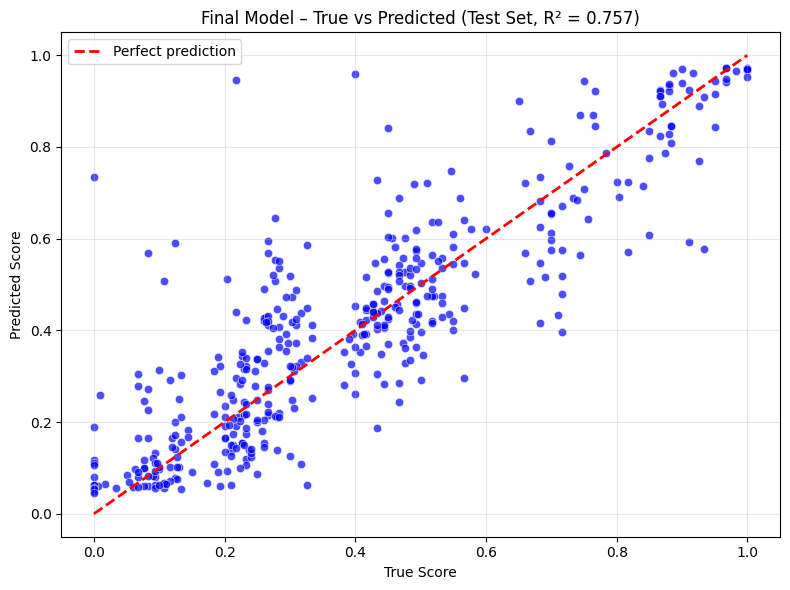

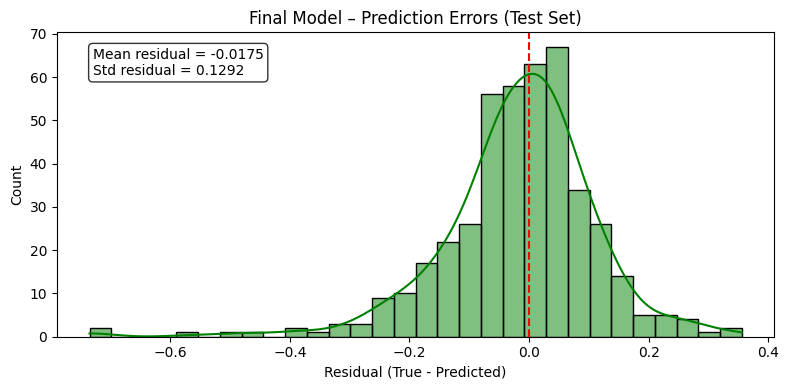

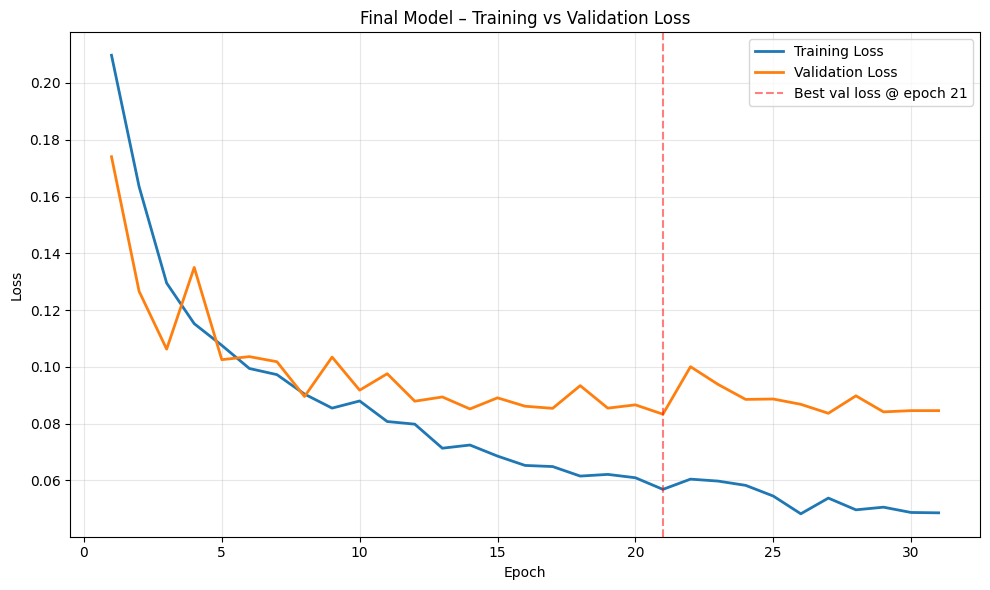

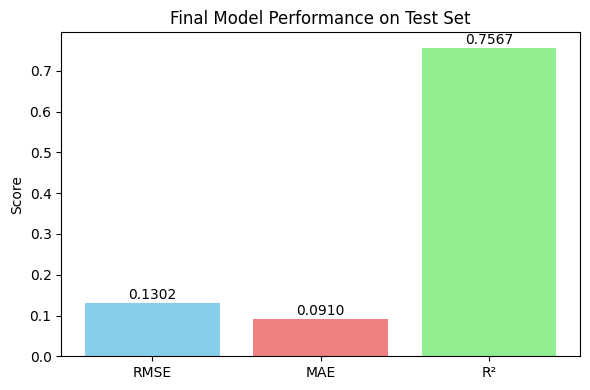

✅ All plots generated from final model results.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Load test predictions
test_df = pd.read_csv(os.path.join(SAVE_DIR, "final_test_predictions.csv"))

# Load training history
history_df = pd.read_csv(os.path.join(SAVE_DIR, "final_training_history.csv"))

# Compute final metrics from test set
final_rmse = np.sqrt(((test_df["y_true"] - test_df["y_pred"]) ** 2).mean())
final_mae = (test_df["y_true"] - test_df["y_pred"]).abs().mean()
final_r2 = 1 - ( ((test_df["y_true"] - test_df["y_pred"])**2).sum() / ((test_df["y_true"] - test_df["y_true"].mean())**2).sum() )

print(f"Loaded test metrics: RMSE = {final_rmse:.4f}, MAE = {final_mae:.4f}, R² = {final_r2:.4f}")

# ------------------------------------------------------------
# 1. Scatter plot: True vs Predicted (final test set)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x=test_df["y_true"], y=test_df["y_pred"], alpha=0.7, color='blue')
min_val = min(test_df["y_true"].min(), test_df["y_pred"].min())
max_val = max(test_df["y_true"].max(), test_df["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title(f"Final Model – True vs Predicted (Test Set, R² = {final_r2:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_scatter.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 2. Residuals histogram (final test set)
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.histplot(test_df["residual"], bins=30, kde=True, color='green')
plt.xlabel("Residual (True - Predicted)")
plt.title(f"Final Model – Prediction Errors (Test Set)")
plt.axvline(0, color='r', linestyle='--')
plt.text(0.05, 0.95, f'Mean residual = {test_df["residual"].mean():.4f}\nStd residual = {test_df["residual"].std():.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_residuals.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 3. Training & Validation Loss Curve (from final training)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label='Training Loss', linewidth=2)
plt.plot(history_df["epoch"], history_df["val_loss"], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model – Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark best validation epoch
best_val_epoch = history_df["val_loss"].idxmin() + 1
plt.axvline(best_val_epoch, color='r', linestyle='--', alpha=0.5,
            label=f'Best val loss @ epoch {best_val_epoch}')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_loss_curve.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 4. Optional: Bar chart of final test metrics
# ------------------------------------------------------------
metrics = {'RMSE': final_rmse, 'MAE': final_mae, 'R²': final_r2}
plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('Score')
plt.title('Final Model Performance on Test Set')
for i, (k, v) in enumerate(metrics.items()):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_metrics_bar.png"), dpi=150)
plt.show()

print("✅ All plots generated from final model results.")

Predictions file for fold None not found.
Loss curve file for fold None not found.


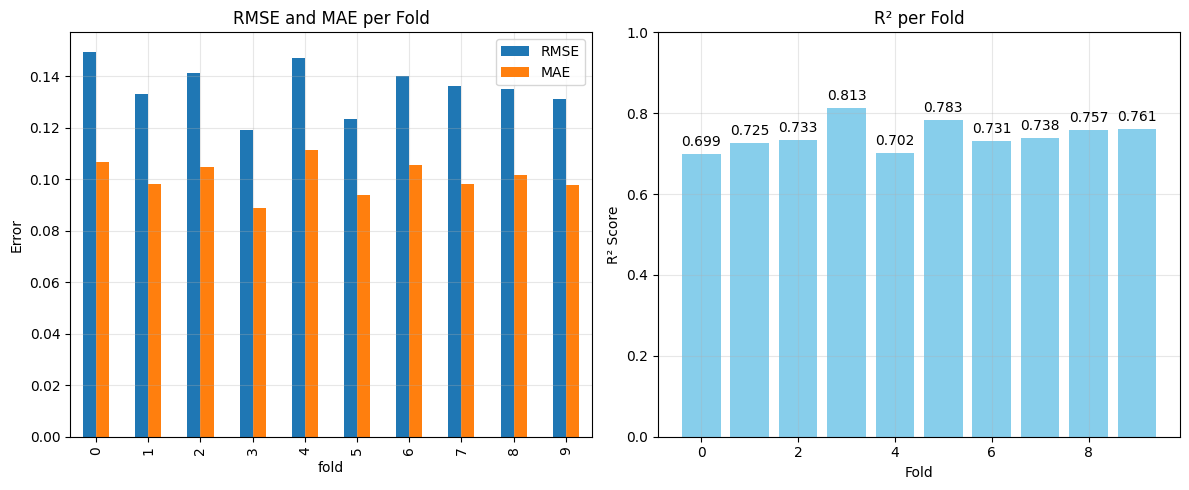

✅ All plots generated successfully from saved data.


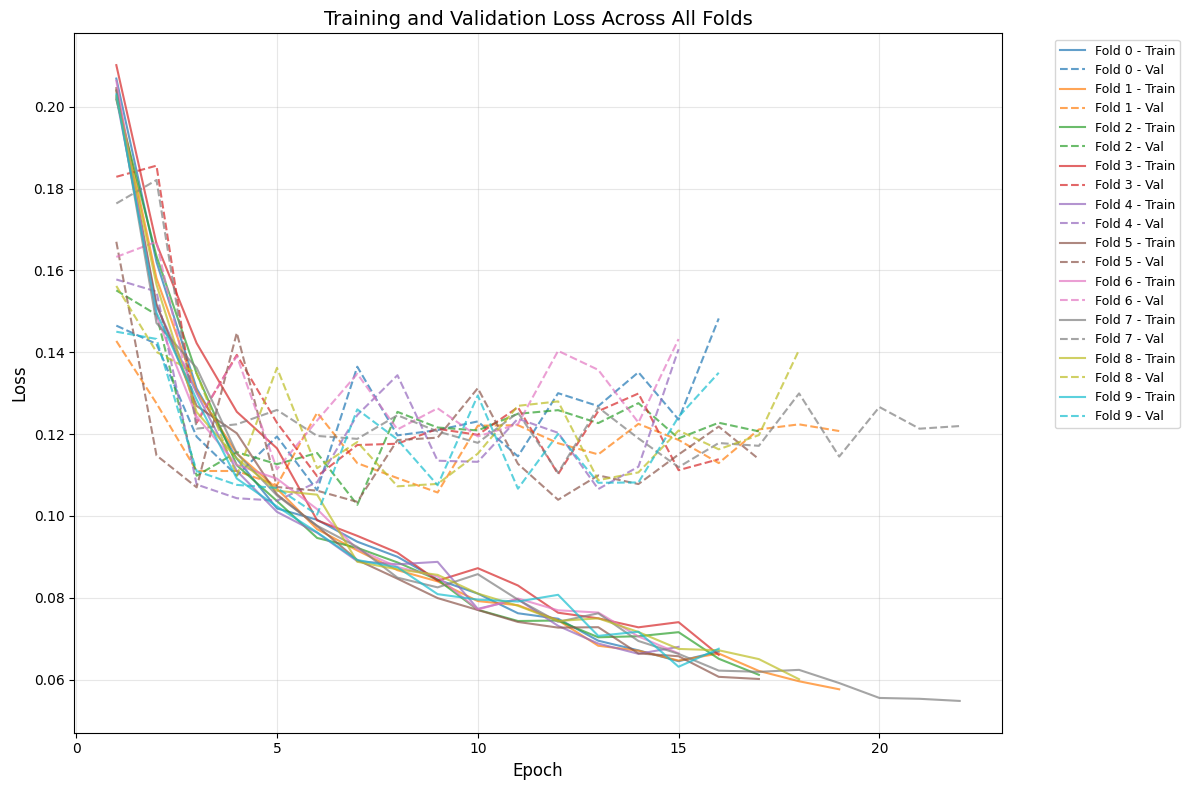

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os
import numpy as np

# Load results
results_df = pd.read_csv(os.path.join(SAVE_DIR, "cv_results.csv"))

# Load best_fold
with open(os.path.join(SAVE_DIR, "best_fold.json"), "r") as f:
    best_fold = json.load(f)["best_fold"]

# ------------------------------------------------------------
# 1. Scatter plot: True vs Predicted for the best fold only
# ------------------------------------------------------------
best_pred_file = os.path.join(SAVE_DIR, f"predictions_fold{best_fold}.csv")
if os.path.exists(best_pred_file):
    df_best = pd.read_csv(best_pred_file)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df_best["y_true"], y=df_best["y_pred"], alpha=0.7, color='blue')
    min_val = min(df_best["y_true"].min(), df_best["y_pred"].min())
    max_val = max(df_best["y_true"].max(), df_best["y_pred"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    plt.xlabel("True Score")
    plt.ylabel("Predicted Score")
    plt.title(f"Best Model (Fold {best_fold}) – True vs Predicted Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"best_fold_scatter.png"), dpi=150)
    plt.show()
else:
    print(f"Predictions file for fold {best_fold} not found.")

# ------------------------------------------------------------
# 2. Residuals histogram for best fold
# ------------------------------------------------------------
if os.path.exists(best_pred_file):
    df_best = pd.read_csv(best_pred_file)
    df_best["residual"] = df_best["y_true"] - df_best["y_pred"]
    plt.figure(figsize=(8, 4))
    sns.histplot(df_best["residual"], bins=30, kde=True)
    plt.xlabel("Residual (True - Predicted)")
    plt.title(f"Best Fold (Fold {best_fold}) – Prediction Errors")
    plt.axvline(0, color='r', linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"best_fold_residuals.png"), dpi=150)
    plt.show()

# ------------------------------------------------------------
# 3. Training vs Validation loss curves for the best fold
# ------------------------------------------------------------
loss_file = os.path.join(SAVE_DIR, f"loss_curve_fold{best_fold}.csv")
if os.path.exists(loss_file):
    loss_df = pd.read_csv(loss_file)
    plt.figure(figsize=(10, 6))
    plt.plot(loss_df["epoch"], loss_df["train_loss"], label='Training Loss', linewidth=2)
    plt.plot(loss_df["epoch"], loss_df["val_loss"], label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Best Fold (Fold {best_fold}) – Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Mark best validation epoch
    best_val_epoch = loss_df["val_loss"].idxmin() + 1
    plt.axvline(best_val_epoch, color='r', linestyle='--', alpha=0.5,
                label=f'Best val loss @ epoch {best_val_epoch}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"best_fold_loss_curve.png"), dpi=150)
    plt.show()
else:
    print(f"Loss curve file for fold {best_fold} not found.")

# ------------------------------------------------------------
# 4. Bar chart of metrics across all folds
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
results_df.set_index("fold")[["RMSE", "MAE"]].plot(kind="bar", ax=ax1, legend=True)
ax1.set_title("RMSE and MAE per Fold")
ax1.set_ylabel("Error")
ax1.grid(True, alpha=0.3)

ax2.bar(results_df["fold"], results_df["R²"], color='skyblue')
ax2.set_xlabel("Fold")
ax2.set_ylabel("R² Score")
ax2.set_title("R² per Fold")
ax2.set_ylim(0, 1)
for i, v in enumerate(results_df["R²"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "metrics_all_folds.png"), dpi=150)
plt.show()

print("✅ All plots generated successfully from saved data.")

# ------------------------------------------------------------
# 5. Training & Validation Loss Across All Folds (overlaid)
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Use a colormap to distinguish folds
colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))

for i, fold in enumerate(results_df["fold"]):
    loss_file = os.path.join(SAVE_DIR, f"loss_curve_fold{fold}.csv")
    if os.path.exists(loss_file):
        loss_df = pd.read_csv(loss_file)

        # Plot training loss (solid line)
        plt.plot(loss_df["epoch"], loss_df["train_loss"],
                 color=colors[i], linestyle='-', linewidth=1.5, alpha=0.7,
                 label=f'Fold {fold} - Train')

        # Plot validation loss (dashed line, same color)
        plt.plot(loss_df["epoch"], loss_df["val_loss"],
                 color=colors[i], linestyle='--', linewidth=1.5, alpha=0.7,
                 label=f'Fold {fold} - Val')
    else:
        print(f"Loss curve file for fold {fold} not found.")

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Across All Folds', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "all_folds_loss_curves.png"), dpi=150)
plt.show()

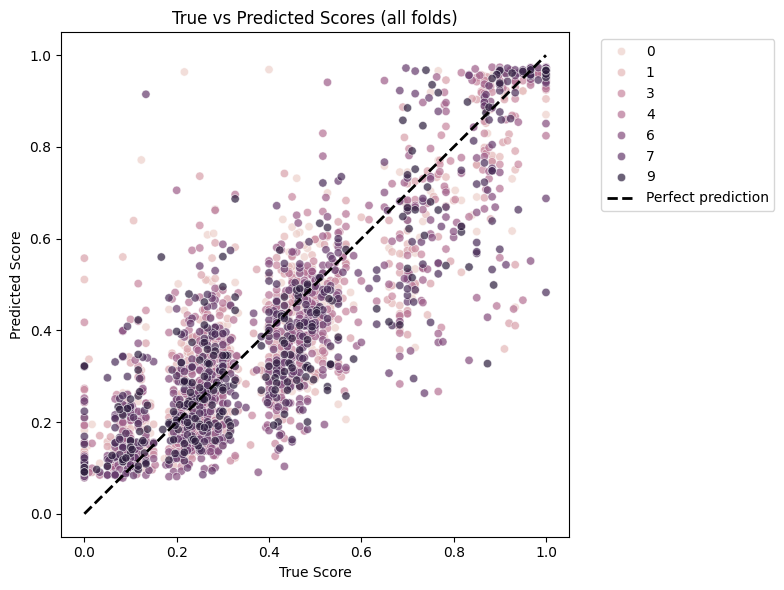

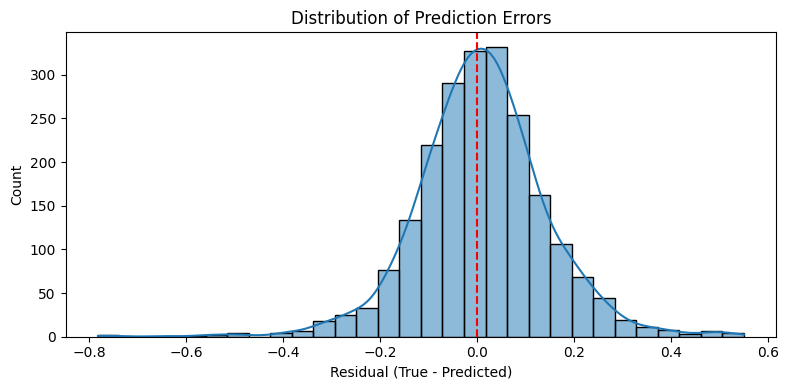

KeyError: "None of ['fold'] are in the columns"

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

all_true = []
all_pred = []
fold_ids = []
results = []
histories = []

for fold in range(cv.get_n_splits()):  # or use 'count' after loop
    pred_file = os.path.join(SAVE_DIR, f"predictions_fold{fold}.csv")
    if os.path.exists(pred_file):
        df_fold = pd.read_csv(pred_file)
        all_true.extend(df_fold["y_true"].values)
        all_pred.extend(df_fold["y_pred"].values)
        fold_ids.extend([fold] * len(df_fold))

df_all = pd.DataFrame({"y_true": all_true, "y_pred": all_pred, "fold": fold_ids})

plt.figure(figsize=(8, 6))
sns.scatterplot(x="y_true", y="y_pred", hue="fold", data=df_all, alpha=0.7)
# diagonal line (perfect prediction)
min_val = min(df_all["y_true"].min(), df_all["y_pred"].min())
max_val = max(df_all["y_true"].max(), df_all["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Perfect prediction")
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("True vs Predicted Scores (all folds)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "true_vs_predicted_scatter.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 2. Residuals histogram (prediction error)
# ------------------------------------------------------------
df_all["residual"] = df_all["y_true"] - df_all["y_pred"]
plt.figure(figsize=(8, 4))
sns.histplot(df_all["residual"], bins=30, kde=True)
plt.xlabel("Residual (True - Predicted)")
plt.title("Distribution of Prediction Errors")
plt.axvline(0, color='r', linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "residuals_hist.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 3. Bar chart of metrics per fold (RMSE, MAE, R²)
# ------------------------------------------------------------
results_df = pd.DataFrame(results)  # results is the list of dicts you already collected
results_df.set_index("fold", inplace=True)

ax = results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(10, 5), legend=True)
ax.set_xlabel("Fold")
ax.set_ylabel("Error")
ax.set_title("RMSE and MAE per Fold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "metrics_per_fold_bar.png"), dpi=150)
plt.show()

# R² per fold
plt.figure(figsize=(8, 4))
plt.bar(results_df.index, results_df["R²"], color='skyblue')
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("R² per Fold")
plt.ylim(0, 1)
for i, v in enumerate(results_df["R²"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "r2_per_fold.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 4. Training vs Validation Loss curves (if you stored histories)
# ------------------------------------------------------------
if 'histories' in locals() and histories:
    plt.figure(figsize=(10, 6))
    for i, hist in enumerate(histories):
        plt.plot(hist.history['loss'], label=f'Fold {i} train', linestyle='-', alpha=0.7)
        plt.plot(hist.history['val_loss'], label=f'Fold {i} val', linestyle='--', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss per Fold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "loss_curves.png"), dpi=150)
    plt.show()
else:
    print("No history objects found. To plot loss curves, store `history` from model.fit().")

# Find index of best fold (if you didn't already store best_fold, compute it)
if 'best_fold' not in locals():
    # Fallback: find fold with highest R² from 'results'
    best_fold = max(results, key=lambda x: x['R²'])['fold']

# Plot training & validation loss for that fold
best_history = histories[best_fold]

plt.figure(figsize=(10, 6))
plt.plot(best_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(best_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Best Fold (Fold {best_fold}) – Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Optional: mark the epoch where validation loss was lowest
best_val_epoch = np.argmin(best_history.history['val_loss'])
plt.axvline(best_val_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best val loss @ epoch {best_val_epoch}')
plt.legend()

# Save and show
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"best_fold_{best_fold}_loss_curve.png"), dpi=150)
plt.show()

print(f"Best validation loss reached at epoch {best_val_epoch} with value {best_history.history['val_loss'][best_val_epoch]:.4f}")

# Load predictions from the best fold
best_pred_file = os.path.join(SAVE_DIR, f"predictions_fold{best_fold}.csv")
if os.path.exists(best_pred_file):
    df_best = pd.read_csv(best_pred_file)

    # Scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df_best["y_true"], y=df_best["y_pred"], alpha=0.7, color='blue')

    # Perfect prediction line
    min_val = min(df_best["y_true"].min(), df_best["y_pred"].min())
    max_val = max(df_best["y_true"].max(), df_best["y_pred"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

    plt.xlabel("True Score")
    plt.ylabel("Predicted Score")
    plt.title(f"Best Model (Fold {best_fold}) – True vs Predicted Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save the plot
    plt.savefig(os.path.join(SAVE_DIR, f"best_fold_{best_fold}_scatter.png"), dpi=150)
    plt.show()

    # Optional: add R² and MAE annotations on the plot
    from sklearn.metrics import r2_score, mean_absolute_error
    r2 = r2_score(df_best["y_true"], df_best["y_pred"])
    mae = mean_absolute_error(df_best["y_true"], df_best["y_pred"])
    plt.text(0.05, 0.95, f'R² = {r2:.4f}\nMAE = {mae:.4f}',
             transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.savefig(os.path.join(SAVE_DIR, f"best_fold_{best_fold}_scatter_with_stats.png"), dpi=150)
    plt.show()

else:
    print(f"Predictions file for fold {best_fold} not found at {best_pred_file}")

In [ ]:
import math
from gensim.test.utils import datapath
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

predicted_scores = []
actual_scores = []
indices = []

NUM_CLASSES = 2
model = get_model()
AX_LEN = 80
EMB_DIM = 100
NUM_CLASSES = 2

def testContent(content):
    if isinstance(content, str):
        content = [content]

    if len(content) >= 1 and content[0].strip() != "":
        X_test_seq = np.array([
            essay_to_sequence_cached(essay, ft, 80)
            for essay in content
        ])

        lstm_model = get_model()
        lstm_model.load_weights('/content/drive/MyDrive/Model+Data/best_lstm_model_v4.h5')
        preds = lstm_model.predict(X_test_seq).flatten()
    else:
        preds = 0.1

    return preds

for index, row in X1.iterrows():
        jawaban = row['jawaban']
        kunci = row['kunci jawaban']
        actual = row['domain1_score']
        answer = testContent(jawaban)
        parameter = testContent(kunci)

        # print(f"Index: {index}, Jawaban: {jawaban}, Predicted Score: {answer}")

        pred_value = float(answer[0]) if isinstance(answer, (list, np.ndarray)) else float(answer)

        predicted_scores.append(pred_value)
        actual_scores.append(actual)
        indices.append(index)

    # print(f"Index: {index}, Predicted: {pred_value}, Actual: {actual}")

# --- Plotting ---
plt.figure(figsize=(12, 6))

# Line plots
plt.plot(indices, actual_scores, label='Actual (domain1_score)', marker='o')
plt.plot(indices, predicted_scores, label='Predicted Score', marker='x')

# Annotate each point with index
for i, idx in enumerate(indices):
    plt.text(idx, actual_scores[i], str(idx), fontsize=8, ha='right', va='bottom')
    plt.text(idx, predicted_scores[i], str(idx), fontsize=8, ha='left', va='top')

plt.xlabel("Row Index")
plt.ylabel("Score")
plt.title("Predicted vs Actual Scores per Row")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()